# CSE 25 - Introduction to Artificial Intelligence
## Week 6 Tuesday: Neural networks

**Learning Objectives:**

- Extend the binary classification model to multi-class classification using **softmax**
- Compute multi-class cross-entropy loss using **one-hot encoding**
- Identify common activation functions (sigmoid, tanh, ReLU) and explain why nonlinearity is required between layers
- Explain why XOR cannot be solved by a single linear layer model
- Describe how hidden layers increase model expressivity
- Explain the role of backpropagation and autodiff in a neural network with hidden layers

Instructions

Use your copy of this notebook on Datahub and complete it during class. Work through the cells below **in order**. You may discuss with your neighbors, but make sure you understand each step yourself.


SUBMISSION:
When finished, download it as a PDF and upload it to Gradescope under `In-Class – Week 6 Tuesday` to receive credit. To download it as a PDF, on DataHub go to `File -> Save and Export Notebook As -> PDF`.

#### Context

Previously, we learned how to compute gradients efficiently using **backpropagation** for a single-layer model (sigmoid + binary cross-entropy).

We saw:

- Why finite-difference gradient computation is inefficient  
- How the chain rule enables efficient gradient computation  
- How gradients are used to update parameters and reduce loss  

However, our model was still a single linear layer.

Today, we go one step further. In this worksheet, we will extend the binary classification model to **multi-class classification** and introduce hidden layers and activation functions.

We have covered three foundational linear models so far:

- **Linear Regression**: Uses the identity activation function and is trained with Mean Squared Error (MSE) loss. This model is suitable for regression tasks where the output is continuous.

- **Perceptron**: Uses the sign (or step) activation function and is trained using the perceptron update rule, which can be interpreted as minimizing the perceptron loss. This model is designed for binary classification with hard decision boundaries.

- **Logistic Regression**: Uses the sigmoid activation function and is trained with Binary Cross-Entropy (BCE) loss. This model outputs probabilities for binary classification.


*Confusing terminology* Logistic regression is used for classification tasks!


Although these models differ in activation functions and loss functions, they all share the same underlying structure: a single linear decision boundary.

In [33]:
# Fix PATH so the graphviz 'dot' binary can be found.
# This is needed locally (e.g. Homebrew on macOS) and on some JupyterHub environments.
# If you see: FileNotFoundError: [Errno 2] No such file or directory: PosixPath('dot')
# run this cell, or install graphviz:
#   macOS:  brew install graphviz
#   Linux:  sudo apt-get install graphviz

import os
import shutil

if shutil.which('dot') is None:
    # Common locations for the graphviz dot binary
    candidate_paths = [
        '/opt/homebrew/bin',        # Apple Silicon Homebrew
        '/usr/local/bin',           # Intel Homebrew / Linux
        '/usr/bin',                 # system default
        '/usr/local/graphviz/bin',  # some DataHub / conda setups
        '/opt/conda/bin',           # conda environments
    ]
    for p in candidate_paths:
        if os.path.isfile(os.path.join(p, 'dot')):
            os.environ['PATH'] = p + os.pathsep + os.environ.get('PATH', '')
            print(f'Added {p} to PATH for graphviz dot binary.')
            break
    else:
        print('WARNING: graphviz dot binary not found. '
              'Install it with:  brew install graphviz  (macOS) '
              'or  sudo apt-get install graphviz  (Linux)')
else:
    print('graphviz dot binary found at:', shutil.which('dot'))

graphviz dot binary found at: /opt/homebrew/bin/dot


We use structured graphs to represent the **architecture** of a model.

Rectangle nodes are values.
Circle nodes are functions.

In [34]:
# This cell produces some visualizations of the
# models we've discusses so far. You do not need
# to be able to reproduce or understand the code itself.

# !pip install graphviz
from graphviz import Digraph

def val(dot, name, label=None):
    dot.node(name, label if label else name, shape="box")

def fn(dot, name, label):
    dot.node(name, label, shape="circle")

def connect(dot, src, dst, weight=None):
    dot.edge(src, dst, label=weight) if weight else dot.edge(src, dst)


def add_neuron(dot, suffix, activation, inputs, box_neuron=False, cluster_label="Neuron"):
    """Creates Σ -> z -> act structure."""
    s_id, z_id, a_id = f"sum{suffix}", f"z{suffix}", f"act{suffix}"
    z_lab = f"z{suffix}" if suffix else "z"
    
    if box_neuron:
        with dot.subgraph(name=f"cluster_{suffix}") as c:
            c.attr(label=cluster_label, style="dashed")
            fn(c, s_id, "Σ")
            val(c, z_id, z_lab)
            fn(c, a_id, activation)
            connect(c, s_id, z_id)
            connect(c, z_id, a_id)
    else:
        fn(dot, s_id, "Σ")
        val(dot, z_id, z_lab)
        fn(dot, a_id, activation)
        connect(dot, s_id, z_id)
        connect(dot, z_id, a_id)

    for src, weight in inputs:
        connect(dot, src, s_id, weight)
        
    return a_id


def common_graph(loss_label, activation_label, output_label, box_neuron=False):
    dot = Digraph(graph_attr={"rankdir": "LR"})
    
    val(dot, "one", "1"); val(dot, "x1", "x₁"); val(dot, "x2", "x₂"); val(dot, "y", "y")
    
    last_node = add_neuron(dot, "", activation_label, 
                           [("one", "* b"), ("x1", "* w₁"), ("x2", "* w₂")], box_neuron)
    
    val(dot, "out", output_label); fn(dot, "loss", loss_label); val(dot, "L", "L")
    connect(dot, last_node, "out"); connect(dot, "out", "loss")
    connect(dot, "y", "loss"); connect(dot, "loss", "L")
    return dot

# Standard Models
def general_linear_model_graph(box_neuron=False):return common_graph("L(.)","f(.)","out",box_neuron=box_neuron)
def linear_regression_graph(box_neuron=False): return common_graph("MSE", "id", "ŷ", box_neuron)
def perceptron_graph(box_neuron=False): return common_graph("P_Loss", "sign", "ŷ", box_neuron)
def logistic_regression_graph(box_neuron=False): return common_graph("BCE", "σ", "p", box_neuron)

The computation graph for linear regression.


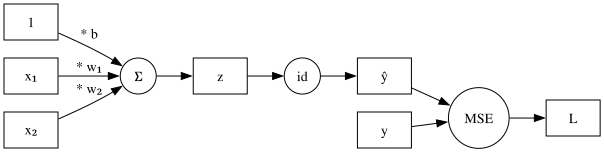

In [35]:
print("The computation graph for linear regression.")

linear_regression_graph()

The computation graph for a perceptron.


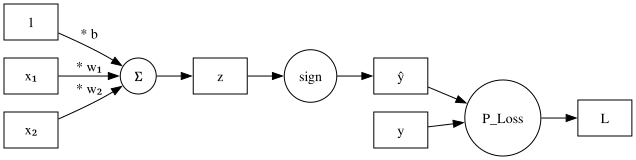

In [36]:
print("The computation graph for a perceptron.")

perceptron_graph()

The computation graph for logistic regression.


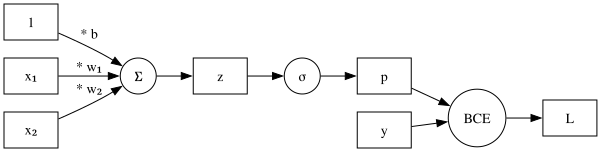

In [37]:
print("The computation graph for logistic regression.")

logistic_regression_graph()

#### A Common Computational Structure

If we look at the three models we just saw, we notice that they all share the same core structure:

1. Compute a weighted sum: $ z = \sum_{i=1}^{n} w_i x_i + b $

2. Apply an activation function: $out = f(.)$

3. Compute a loss: $L(.)$

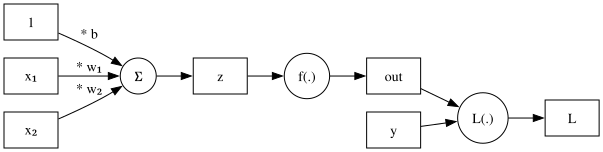

In [38]:
general_linear_model_graph()

#### The Core Computational Unit: A Neuron

The combination of:

- a weighted sum
- followed by an activation function

is often called a **neuron**.

*Note for "multi-layer perceptron" the perceptron is used as a synonym for neuron.*

Visually, we can group:

x → (weighted sum) → z → (activation) → a

into a single computational block.


##### Biological Inspiration

The term *neuron* comes from biology.

A biological neuron:

- Receives signals through dendrites  
- Aggregates those signals  
- Generates an output signal when its internal activation exceeds a threshold  

The artificial neuron abstracts this idea:

- Inputs $x_i$ correspond to incoming signals  
- Weights $w_i$ represent synaptic strength  
- The weighted sum aggregates signals  
- The activation function determines whether and how strongly the unit "fires"

This abstraction dates back to the seminal 1943 paper by McCulloch and Pitts:
W. McCulloch & W. Pitts (1943).  *A Logical Calculus of the Ideas Immanent in Nervous Activity.*

Their model formalized the idea of weighted input aggregation followed by a threshold function, laying the foundation for modern neural networks.

Modern neural networks are inspired by biology, but they are highly simplified mathematical abstractions rather than detailed models of real neurons.


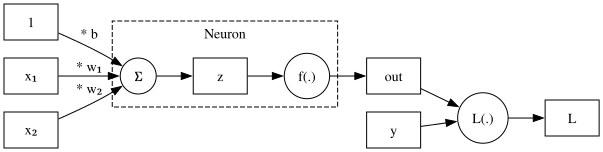

In [39]:
general_linear_model_graph(box_neuron=True)

This boxed structure is the fundamental building block of neural networks. The models we've looked at so far had 1 neuron each.

A neural network consists of many neurons connected together.

The way the neurons are connected together depends on the task at hand.

We'll first see how to use multiple neurons in a single layer for multi-class classification.

Then, we connect multiple neurons into layered networks.

#### Multi-Class Classification

In binary classification, we used the sigmoid function:

$$
p = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

This produces a single probability $p$, which we interpret $p$ as the confidence with which the model predicts that the label of the example is *positive*. From $p$, we can also infer the confidence with which the model predicts that the label of the example is *negative* as $1-p$. This gives a **distribution** of probabilities: a mapping from each possible outcome to the likelihood it will occur. Note: in a distribution, each probabilty must be greater than or equal to $0$ and the sum of the probabilities of all outcomes is $1$.

Consider the multi-class classification problem with $K$ classes.

**One-hot encoding**

To represent true labels for example data points using *one-hot encoding*, the true label for each data point is a list (or vector) where the entry at the index corresponding to the correct class is $1$ and all other entries are $0$.

*There are other choices for representation here, that would lead to different calculations.*

##### Softmax

For multi-class classification, instead of producing one score $z$, the model produces a list of scores:

$$
z_1, z_2, \dots, z_K
$$

The **Softmax** function generalizes the sigmoid to the multi-class setting. It takes the raw scores and converts them into a probability distribution: for each class $\ell$

$$
p_k = \frac{e^{z_k}}{\sum_{\ell=1}^{K} e^{z_\ell}}
$$

By dividing each exponentiated score by the sum of all exponentiated scores, Softmax ensures that:

- $p_k > 0$
- $\sum_{k=1}^{K} p_k = 1$
- Larger $z_k$ leads to larger probability

*Check your understanding*

Suppose we have $K = 3$ classes (cat, dog, bird) and a single input $x$. The model produces raw scores $z_1 = 2.0$ and $z_2 = 1.0$ and $z_3 = 0.1$, compute the softmax probabilities $p_1$ and $p_2$ and $p_3$.

`YOUR ANSWER HERE`

##### Categorical Cross-Entropy Loss
In binary classification, we use binary cross-entropy (BCE) loss:

$$
\mathcal{L} = -\big[y \log p + (1-y)\log(1-p)\big]
$$

For multi-class classification, the model needs to predict a confidence for each possible outcome (label, class).
BCE generalizes to **Categorical Cross-Entropy** by summing the error across all $K$ classes:

$$
\mathcal{L} = -\sum_{k=1}^{K} y_k \log p_k
$$

With one-hot encoding, for each input example the true label values for each class will be $0$ for all incorrect classes and $1$ for the (one) correct class. The terms in the summation corresponding to each incorrect class are therefore $0$. We can simplify the summation above to get a calculation that only cares about the probability assigned to the correct class:

$$\mathcal{L} = -\log(p_{\text{correct}})$$

- If the model is confident in the right answer ($p_{\text{correct}} \approx 1$), the loss is near **0**.
- If the model assigns a low probability to the right answer, the loss becomes very large.

*Check your understanding*

In the same example as before, with $K=3$ and the scores $z_1 = 2.0$ and $z_2 = 1.0$ and $z_3 = 0.1$, what is the cross-entropy loss if the true class is cat (class $1$)? What about if the true class is dog (class $2$)?

`YOUR ANSWER HERE`

The computation graph of softmax logistic regression for multi-class classification has a neuron for each class.

The model learns parameters for each feature and each class, and then combines the scores using softmax to produce the probability distribution across classes.

In [40]:
def softmax_logistic_regression_graph(box_neuron=False):
    dot = Digraph(graph_attr={"rankdir": "LR", "labelloc": "t", "label": "Softmax Logistic Regression"})
    
    # Declare inputs first
    val(dot, "one1", "1"); val(dot, "one2", "1")
    val(dot, "x1", "x₁"); val(dot, "x2", "x₂")
    val(dot, "y", "y")

    # Define Neuron 1 (Top)
    n1 = add_neuron(dot, "1", "id", [("x1", "* w₁₁"), ("x2", "* w₂₁"), ("one1", "* b₁")], 
                    box_neuron, "Neuron (Class 1)")
    
    # Define Neuron 2 (Bottom)
    n2 = add_neuron(dot, "2", "id", [("x1", "* w₁₂"), ("x2", "* w₂₂"), ("one2", "* b₂")], 
                    box_neuron, "Neuron (Class 2)")

    fn(dot, "softmax", "softmax")
    connect(dot, n1, "softmax"); connect(dot, n2, "softmax")
    
    val(dot, "p1", "p₁"); val(dot, "p2", "p₂")
    connect(dot, "softmax", "p1"); connect(dot, "softmax", "p2")
    
    fn(dot, "loss", "CCE")
    connect(dot, "p1", "loss"); connect(dot, "p2", "loss"); connect(dot, "y", "loss")
    val(dot, "L", "L"); connect(dot, "loss", "L")
    
    return dot


A two dimensional input with two neurons (one for each of two classes) and two outputs.


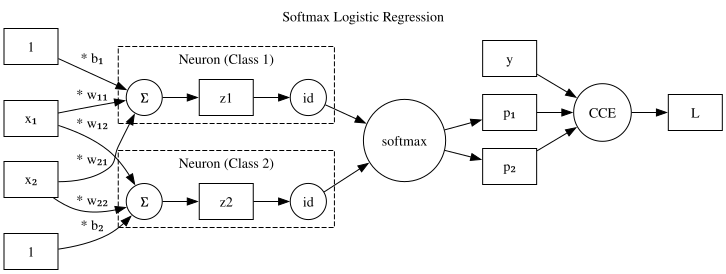

In [41]:
print("A two dimensional input with two neurons (one for each of two classes) and two outputs.")

softmax_logistic_regression_graph(box_neuron=True)

Each neuron computes a raw linear score $zk$; the softmax step outside converts all scores into a probability distribution.

**NOTE: This is still a single layer model**

Even though the diagram shows **two neurons** (one per class) and a softmax step, this is still a **single-layer model**.

- Each class score is just a **weighted sum of the inputs**:

$$
z_1 = w_{11}x_1 + w_{21}x_2 + b_1, \qquad
z_2 = w_{12}x_1 + w_{22}x_2 + b_2
$$

- There are **no hidden layers**.
- Softmax only converts scores into probabilities. It does **not** add depth or extra learning capacity.

Because of this, the model can only learn **linear decision boundaries**.  It cannot represent curved or complex boundaries (for example, XOR).

#### The XOR Problem: A Challenge for Single-Layer Linear Models

The XOR (exclusive OR) function outputs 1 only when its two binary inputs differ.

| x1 | x2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

If we plot the four possible input combinations, we will see that no single straight line can separate the points where XOR is 1 from those where it is 0.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, VBox, HBox

# XOR dataset
X_xor = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]
y_xor = [-1, 1, 1, -1]  # XOR labels for perceptron

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def plot_xor_model(w1=0.0, w2=0.0, b=0.0, activation="sign"):
    
    w = [w1, w2]

    # Separate points by class (based on original XOR labels)
    X_pos = [x for x, y in zip(X_xor, y_xor) if y == 1]
    X_neg = [x for x, y in zip(X_xor, y_xor) if y == -1]

    plt.figure(figsize=(4, 4))
    plt.scatter([x[0] for x in X_pos], [x[1] for x in X_pos],
                marker='x', s=100, label='Class +1')
    plt.scatter([x[0] for x in X_neg], [x[1] for x in X_neg],
                marker='o', s=100, label='Class 0')

    # Decision boundary: w1*x1 + w2*x2 + b = 0
    x1_vals = np.linspace(-0.5, 1.5, 100)

    if w1 == 0 and w2 == 0:
        plt.text(0.5, 0.5, "No decision boundary\n(w1=0, w2=0)",
                 fontsize=12, ha='center', va='center',
                 transform=plt.gca().transAxes)
    elif w2 != 0:
        x2_vals = [-(w1/w2)*x1 - b/w2 for x1 in x1_vals]
        plt.plot(x1_vals, x2_vals, linestyle='--', label='Decision boundary')
    elif w1 != 0:
        plt.axvline(x=-b/w1, linestyle='--', label='Decision boundary')

    # Predictions
    for x, y_true in zip(X_xor, y_xor):
        score = w[0] * x[0] + w[1] * x[1] + b

        if activation == "sign":
            y_pred = 1 if score >= 0 else 0
            label_text = f"Pred: {y_pred}"

        elif activation == "sigmoid":
            p = sigmoid(score)
            y_pred = 1 if p >= 0.5 else 0
            label_text = f"p={p:.2f}"

        plt.text(x[0] + 0.05, x[1] + 0.05,
                 label_text, fontsize=9)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"XOR with {activation} activation")
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()


interact(
    plot_xor_model,
    w1=FloatSlider(value=1, min=-5, max=5, step=0.1, description='w1'),
    w2=FloatSlider(value=1, min=-5, max=5, step=0.1, description='w2'),
    b=FloatSlider(value=0, min=-5, max=5, step=0.1, description='b'),
    activation=Dropdown(
        options=["sign", "sigmoid"],
        value="sign",
        description="activation"
    )
)

interactive(children=(FloatSlider(value=1.0, description='w1', max=5.0, min=-5.0), FloatSlider(value=1.0, desc…

<function __main__.plot_xor_model(w1=0.0, w2=0.0, b=0.0, activation='sign')>

Q: Try all combinations of `w1`, `w2`, and `b` in the widget above. Can you find any collection of values that perfectly separates the class + 1 and class -1 XOR inputs using a single linear decision boundary? If yes, write down the values. If no, explain *geometrically* why it is impossible.

`YOUR ANSWER HERE`

Q: Switch between `sign` activation and `sigmoid` activation to compare the perceptron and logistic regression models. What do you notice?

`YOUR ANSWER HERE`

`REMOVE FROM CLASS VERSION`
>Switching between `sign` and `sigmoid` compares the perceptron and logistic regression
> models on the XOR problem. Neither can solve it — but notice that `sigmoid` shows a *soft*
> probability at each point rather than a hard 0/1 decision. Both are still limited to a single
> linear decision boundary.

#### Multi-Layer Perceptron (MLP) or Feed Forward Neural Network (FFNN)

A **hidden layer** is a layer of neurons whose outputs are not the final prediction.
Hidden layers sit between the inputs and the output.

- The input layer contains the input values $(x_1, x_2, \dots, x_n)$.
- A hidden layer produces intermediate outputs.
- The output layer produces the final prediction. The inputs to the output layer are the intermediate outputs from the hidden layer.

We describe the **architecture** of a multi-layer perceptron by specifying the number of inputs, then the number of hidden neurons in each layer, then the number of output neurons.

Roots of **Multi-Layer Perceptrons (MLP)**: McCulloch and Pitts (1943) introduced a thresholded neuron model without a learning rule.  The original perceptron (Rosenblatt, 1958) was a single-layer model with a threshold (step) activation function and the perceptron update rule for learning. Modern MLPs stack multiple layers and typically use differentiable activation functions such as sigmoid, tanh, or ReLU.

##### What changes when we add a hidden layer?

We introduce new intermediate outputs computed from the inputs. Instead of:

x → (weighted sum) → output

We now have:

x → (weighted sum) → activation → (weighted sum of those intermediate outputs) → output

The model is now a composition of functions. The output depends on the weights through these intermediate values.

To compute gradients efficiently in this composed structure, we apply backpropagation.

### Common Activation Functions

In neural networks, the activation function introduces nonlinearity.
Without it, stacking layers would still produce a linear model.

Three commonly used activation functions are:

**Sigmoid**
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
- Output range: (0, 1)
- Typically used in the output layer for binary classification.

**Tanh**
$$
\tanh(z) = \frac{e^{z} - e^{-z}}{e^{-z} + e^{z}}
$$

- Output range: (-1, 1)
- Zero-centered

**ReLU (Rectified Linear Unit)**
$$
\text{ReLU}(z) = \max(0, z)
$$
- Commonly used in hidden layers
- Computationally simple
- ReLU (or variants such as Leaky ReLU) is most commonly used in hidden layers.


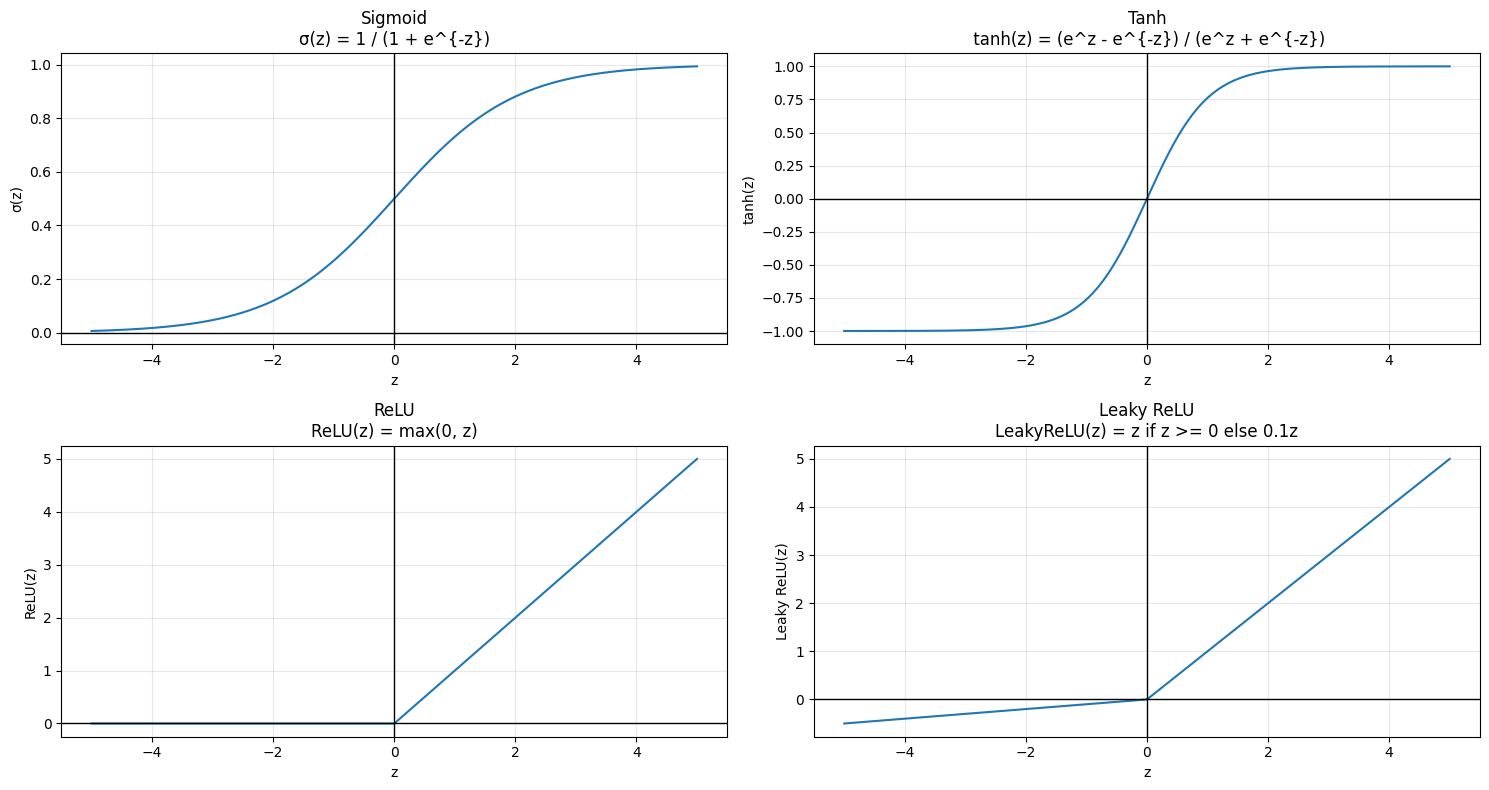

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid_plot(z):
    return 1 / (1 + np.exp(-z))

def tanh_plot(z):
    return np.tanh(z)

def relu_plot(z):
    return np.maximum(0, z)

def leaky_relu_plot(z, alpha=0.1):
    return np.where(z >= 0, z, alpha * z)

z = np.linspace(-5, 5, 400)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Sigmoid
axes[0, 0].plot(z, sigmoid_plot(z))
axes[0, 0].set_title("Sigmoid\nσ(z) = 1 / (1 + e^{-z})")
axes[0, 0].set_xlabel("z")
axes[0, 0].set_ylabel("σ(z)")
axes[0, 0].axhline(0,color='black', linewidth=1)
axes[0, 0].axvline(0,color='black', linewidth=1)
axes[0, 0].grid(True, alpha=0.3)

# Tanh
axes[0, 1].plot(z, tanh_plot(z))
axes[0, 1].set_title("Tanh\n tanh(z) = (e^z - e^{-z}) / (e^z + e^{-z})")
axes[0, 1].set_xlabel("z")
axes[0, 1].set_ylabel("tanh(z)")
axes[0, 1].axhline(0,color='black', linewidth=1)
axes[0, 1].axvline(0,color='black', linewidth=1)
axes[0, 1].grid(True, alpha=0.3)
# ReLU
axes[1, 0].plot(z, relu_plot(z))
axes[1, 0].set_title("ReLU\nReLU(z) = max(0, z)")
axes[1, 0].set_xlabel("z")
axes[1, 0].set_ylabel("ReLU(z)")
axes[1, 0].axhline(0,color='black', linewidth=1)
axes[1, 0].axvline(0,color='black', linewidth=1)
axes[1, 0].grid(True, alpha=0.3)

# Leaky ReLU
axes[1, 1].plot(z, leaky_relu_plot(z))
axes[1, 1].set_title("Leaky ReLU\nLeakyReLU(z) = z if z >= 0 else 0.1z")
axes[1, 1].set_xlabel("z")
axes[1, 1].set_ylabel("Leaky ReLU(z)")
axes[1, 1].axhline(0,color='black', linewidth=1)
axes[1, 1].axvline(0,color='black', linewidth=1)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Solving XOR with a Small Neural Network (2–2–1)

XOR cannot be solved with a single linear decision boundary.

To represent XOR, we need a model with a **hidden layer** that creates intermediate outputs, and an output neuron that combines them.

A common minimal example is a **2–2–1** feedforward neural network:

- **2 inputs**: \(x_1, x_2\)
- **2 hidden neurons**
- **1 output neuron**

The key idea is that the hidden layer can create an intermediate representation that makes the classes separable for the final output neuron.


Q: Why is it not enough to just add a second linear layer without a nonlinear activation function?

`YOUR ANSWER HERE`

In [44]:
def xor_mlp_graph(loss_label="BCE", box_neuron=False, activation_label="f(.)"):
    dot = Digraph(graph_attr={"rankdir": "LR"})

    val(dot, "one1", "1"); val(dot, "one2", "1"); val(dot, "one3", "1")
    val(dot, "x1", "x₁"); val(dot, "x2", "x₂"); val(dot, "y", "y")

    # Hidden Layer (with 2 Neurons)
    # Hidden Neuron 1 -> h1
    h1_act = add_neuron(dot, "1", activation_label, 
                        [("x1", "* w₁₁"), ("x2", "* w₁₂"), ("one1", "* b₁")], 
                        box_neuron, "Hidden Neuron 1")
    val(dot, "h1", "h₁")
    connect(dot, h1_act, "h1")

    # Hidden Neuron 2 -> h2
    h2_act = add_neuron(dot, "2", activation_label, 
                        [("x1", "* w₂₁"), ("x2", "* w₂₂"), ("one2", "* b₂")], 
                        box_neuron, "Hidden Neuron 2")
    val(dot, "h2", "h₂")
    connect(dot, h2_act, "h2")

    # Output Layer (with 1 Neuron)
    # Output Neuron -> p
    p_act = add_neuron(dot, "3", activation_label, 
                       [("h1", "* v₁"), ("h2", "* v₂"), ("one3", "* b₃")], 
                       box_neuron, "Output Neuron")
    val(dot, "p", "p")
    connect(dot, p_act, "p")

    # Loss & Final Scalar
    fn(dot, "loss", loss_label)
    val(dot, "L", "L")
    
    connect(dot, "p", "loss")
    connect(dot, "y", "loss")
    connect(dot, "loss", "L")

    return dot

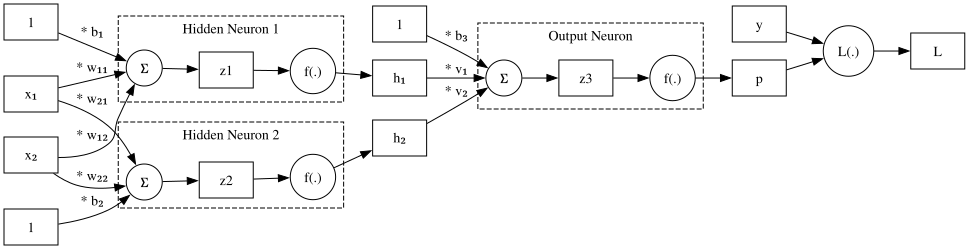

In [45]:
xor_mlp_graph(loss_label="L(.)", box_neuron=True, activation_label="f(.)")

Q: What are the inputs to Hidden Neuron 1?

`YOUR ANSWER HERE`

Q: What are the inputs to Hidden Neuron 2?

`YOUR ANSWER HERE`

Q: What are the inputs to the Output Neuron?

`YOUR ANSWER HERE`

Q: Write the algebraic expression for the output of Hidden Neuron 1, using the weights $w_{11}$, $w_{12}$, bias $b_1$, and activation function $f$.

`YOUR ANSWER HERE`

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0,1,1,0], dtype=int)

def step(z):
    return (z >= 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def activation_fn(z, activation):
    if activation == "sign":
        return step(z)
    elif activation == "sigmoid":
        return sigmoid(z)

def plot_two_hidden(w11=1.0, w12=1.0, b1=-0.5,
                    w21=1.0, w22=1.0, b2=-1.5,
                    activation="sign"):

    threshold = 0.5

    plt.figure(figsize=(6,5))

    # Grid
    x1_vals = np.linspace(-0.5, 1.5, 300)
    x2_vals = np.linspace(-0.5, 1.5, 300)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    Z1 = w11*X1 + w12*X2 + b1
    Z2 = w21*X1 + w22*X2 + b2

    A1 = activation_fn(Z1, activation)
    A2 = activation_fn(Z2, activation)

    H1 = (A1 >= threshold).astype(int)
    H2 = (A2 >= threshold).astype(int)

    region_code = H1*2 + H2

    plt.contourf(
        X1, X2, region_code,
        levels=[-0.1, 0.5, 1.5, 2.5, 3.5],
        alpha=0.15
    )

    # XOR points
    plt.scatter(X[y==1,0], X[y==1,1], s=120, marker="x", label="Class 1")
    plt.scatter(X[y==0,0], X[y==0,1], s=120, marker="o", label="Class 0")

    xs = np.linspace(-0.5, 1.5, 200)

    # Hidden 1 boundary
    if abs(w12) > 1e-9:
        plt.plot(xs, -(w11/w12)*xs - b1/w12, "--", linewidth=2, color="black", label="Hidden 1 (z1=0)")
    elif abs(w11) > 1e-9:
        plt.axvline(x=-b1/w11, linestyle="--", linewidth=2, color="black", label="Hidden 1 (z1=0)")

    # Hidden 2 boundary
    if abs(w22) > 1e-9:
        plt.plot(xs, -(w21/w22)*xs - b2/w22, "--", linewidth=2, color="gray", label="Hidden 2 (z2=0)")
    elif abs(w21) > 1e-9:
        plt.axvline(x=-b2/w21, linestyle="--", linewidth=2, color="gray", label="Hidden 2 (z2=0)")

    # Show activations at XOR points
    for (x1, x2) in X:
        z1 = w11*x1 + w12*x2 + b1
        z2 = w21*x1 + w22*x2 + b2
        a1 = float(activation_fn(z1, activation))
        a2 = float(activation_fn(z2, activation))
        h1 = int(a1 >= threshold)
        h2 = int(a2 >= threshold)

        if activation == "sign":
            txt = f"(h1,h2)=({h1},{h2})"
        else:
            txt = f"p=({a1:.2f},{a2:.2f})"

        plt.text(x1-0.22, x2-0.22, txt, fontsize=8)

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Two Hidden Neurons ({activation})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.25)
    plt.show()

# Sliders
w11_slider = widgets.FloatSlider(value=0.5, min=-3, max=3, step=0.25, description="w11", continuous_update=False)
w12_slider = widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.25, description="w12", continuous_update=False)
b1_slider  = widgets.FloatSlider(value=-0.5, min=-3, max=3, step=0.25, description="b1",  continuous_update=False)

w21_slider = widgets.FloatSlider(value=1.5, min=-3, max=3, step=0.25, description="w21", continuous_update=False)
w22_slider = widgets.FloatSlider(value=2.0, min=-3, max=3, step=0.25, description="w22", continuous_update=False)
b2_slider  = widgets.FloatSlider(value=-1.5, min=-3, max=3, step=0.25, description="b2",  continuous_update=False)

activation_dd = widgets.Dropdown(
    options=[("sign (step)", "sign"), ("sigmoid", "sigmoid")],
    value="sign",
    description="activation",
)

out = widgets.interactive_output(
    plot_two_hidden,
    {
        "w11": w11_slider, "w12": w12_slider, "b1": b1_slider,
        "w21": w21_slider, "w22": w22_slider, "b2": b2_slider,
        "activation": activation_dd,
    }
)

display(activation_dd,
        widgets.HBox([
            widgets.VBox([widgets.HTML("<b>Hidden Neuron 1</b>"),
                          w11_slider, w12_slider, b1_slider]),
            widgets.VBox([widgets.HTML("<b>Hidden Neuron 2</b>"),
                          w21_slider, w22_slider, b2_slider])
        ]),
        out)


Dropdown(description='activation', options=(('sign (step)', 'sign'), ('sigmoid', 'sigmoid')), value='sign')

Output()

The linear boundaries for the two hidden neurons can be used to separate the plane into (up to) four regions.  

Goal: find parameters for the two hidden neurons so that each region only has points of the same class.

>`REMOVE FROM CLASS VERSION`
>w11 = -1.25
>w12 = -0.5
>b1 = 0.25
>w21 = 1.5
>w22 = 0.75
>b2 = -2

Look at the $(h1, h2)$ labels on the four data points when you have a good configuration:

| Input $(x_1, x_2)$ | True label | $(h_1, h_2)$ |
|:---:|:---:|:---:|
| (0, 0) | 0 | ? |
| (0, 1) | 1 | ? |
| (1, 0) | 1 | ? |
| (1, 1) | 0 | ? |

**Fill in the table** for the parameter settings that produce a correct XOR classification.

Q. Are the two "class 1" points mapped to the same $(h1, h2)$ value? Are the two "class 0" points?

`YOUR ANSWER HERE`

Q. Is the resulting $(h_1, h_2)$ representation *linearly separable*?

`YOUR ANSWER HERE`


**Key insight:** The hidden layer transforms the original input space into a new *representation*
$(h1, h2)$ in which the classes are linearly separable. The output neuron takes $(h1, h2)$ as input
and learns a simple linear
classifier in that new space. This is why hidden layers increase expressivity.


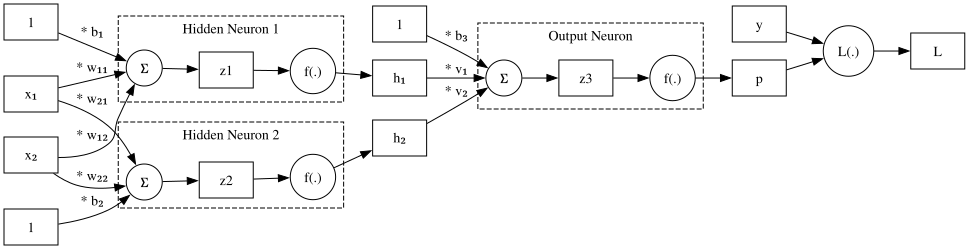

In [47]:
xor_mlp_graph(loss_label="L(.)", box_neuron=True,activation_label="f(.)")

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, VBox, HBox

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0,1,1,0], dtype=int)

def step(z):
    return (np.asarray(z) >= 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def act(z, activation):
    if activation == "sign":
        return step(z)      # {0,1}
    elif activation == "sigmoid":
        return sigmoid(z)   # (0,1)
    else:
        raise ValueError("Unknown activation")

def plot_three_neurons(w11=1.0, w12=1.0, b1=-0.5,
                       w21=1.0, w22=1.0, b2=-1.5,
                       v1=1.0, v2=-2.0, b3=-0.5,
                       hidden_activation="sign",
                       output_activation="sign"):

    plt.figure(figsize=(6,5))

    # Grid
    x1_vals = np.linspace(-0.5, 1.5, 300)
    x2_vals = np.linspace(-0.5, 1.5, 300)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    # Hidden pre-activations
    Z1 = w11*X1 + w12*X2 + b1
    Z2 = w21*X1 + w22*X2 + b2

    # Hidden activations
    A1 = act(Z1, hidden_activation)
    A2 = act(Z2, hidden_activation)

    # Output pre-activation and activation
    Z3 = v1*A1 + v2*A2 + b3
    Yout = act(Z3, output_activation)

    # Decision: default threshold=0.5 for both
    Ypred = (Yout >= 0.5).astype(int)

    # Background regions
    plt.contourf(
        X1, X2, Ypred,
        levels=[-0.1, 0.5, 1.1],
        alpha=0.25,
        colors=["red", "blue"]
    )

    # XOR points
    plt.scatter(X[y==1,0], X[y==1,1], s=120, marker="x", label="Class 1")
    plt.scatter(X[y==0,0], X[y==0,1], s=120, marker="o", label="Class 0")

    xs = np.linspace(-0.5, 1.5, 200)

    # Hidden boundaries (z=0 lines)
    if abs(w12) > 1e-9:
        plt.plot(xs, -(w11/w12)*xs - b1/w12, "--", linewidth=2, color="black", label="Hidden 1 (z1=0)")
    elif abs(w11) > 1e-9:
        plt.axvline(x=-b1/w11, linestyle="--", linewidth=2, color="black", label="Hidden 1 (z1=0)")

    if abs(w22) > 1e-9:
        plt.plot(xs, -(w21/w22)*xs - b2/w22, "--", linewidth=2, color="gray", label="Hidden 2 (z2=0)")
    elif abs(w21) > 1e-9:
        plt.axvline(x=-b2/w21, linestyle="--", linewidth=2, color="gray", label="Hidden 2 (z2=0)")

    # Annotate XOR points
    for (x1, x2), yi in zip(X, y):
        z1 = w11*x1 + w12*x2 + b1
        z2 = w21*x1 + w22*x2 + b2
        a1 = float(act(z1, hidden_activation))
        a2 = float(act(z2, hidden_activation))

        z3 = v1*a1 + v2*a2 + b3
        yout = float(act(z3, output_activation))
        ypred = int(yout >= 0.5)

        if hidden_activation == "sign":
            htxt = f"h=({int(a1)},{int(a2)})"
        else:
            htxt = f"a=({a1:.2f},{a2:.2f})"

        if output_activation == "sign":
            otxt = f"out={int(yout)}, pred={ypred}"
        else:
            otxt = f"p={yout:.2f}, pred={ypred}"

        plt.text(x1+0.04, x2-0.18, htxt, fontsize=9)
        plt.text(x1+0.04, x2-0.32, otxt, fontsize=9)

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Hidden: {hidden_activation} | Output: {output_activation}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.25)
    plt.show()

# Dropdowns
act_options = [("sign", "sign"), ("sigmoid", "sigmoid")]
#act_options = [("sign (step)", "sign"), ("sigmoid", "sigmoid")]

hidden_act_dd = Dropdown(options=act_options, value="sign", description="hidden activation")
output_act_dd = widgets.Dropdown(options=act_options, value="sign", description="output activation")

# Sliders
w11_slider = FloatSlider(value=0.5, min=-3, max=3, step=0.25, description="w11", continuous_update=False)
w12_slider = FloatSlider(value=1.0, min=-3, max=3, step=0.25, description="w12", continuous_update=False)
b1_slider  = FloatSlider(value=-0.5, min=-3, max=3, step=0.25, description="b1",  continuous_update=False)

w21_slider = FloatSlider(value=1.5, min=-3, max=3, step=0.25, description="w21", continuous_update=False)
w22_slider = FloatSlider(value=2.0, min=-3, max=3, step=0.25, description="w22", continuous_update=False)
b2_slider  = FloatSlider(value=-1.5, min=-3, max=3, step=0.25, description="b2",  continuous_update=False)

v1_slider  = FloatSlider(value=-1.0, min=-3, max=3, step=0.25, description="v1", continuous_update=False)
v2_slider  = FloatSlider(value=2.0, min=-3, max=3, step=0.25, description="v2", continuous_update=False)
b3_slider  = FloatSlider(value=0.5, min=-3, max=3, step=0.25, description="b3", continuous_update=False)

hidden1_box = widgets.VBox([widgets.HTML("<b>Hidden Neuron 1</b>"), w11_slider, w12_slider, b1_slider])
hidden2_box = widgets.VBox([widgets.HTML("<b>Hidden Neuron 2</b>"), w21_slider, w22_slider, b2_slider])
output_box  = widgets.VBox([widgets.HTML("<b>Output Neuron</b>"), v1_slider, v2_slider, b3_slider])

out = widgets.interactive_output(
    plot_three_neurons,
    {
        "w11": w11_slider, "w12": w12_slider, "b1": b1_slider,
        "w21": w21_slider, "w22": w22_slider, "b2": b2_slider,
        "v1": v1_slider,  "v2": v2_slider,  "b3": b3_slider,
        "hidden_activation": hidden_act_dd,
        "output_activation": output_act_dd,
    }
)

display(widgets.HBox([hidden_act_dd, output_act_dd]),
        widgets.HBox([hidden1_box, hidden2_box, output_box]),
        out)


Output()

Using the parameters for the two hidden neurons you found above, look for values of the output neuron weights and bias so that all the points are classified correctly.

Q: What happens when you change the activation functions for the hidden neurons or the output neuron?

`YOUR ANSWER`

Gradient descent with binary cross-entropy could be used to learn the model parameters that fit the XOR problem.

#### Autodiff

As we add hidden layers, the number of parameters grows quickly.

Each weight now influences the final output through multiple intermediate computations.
Computing all derivatives by hand becomes impractical.

In the single-layer case, we derived gradients explicitly.
For example, we computed derivatives such as:

$$
\frac{\partial \mathcal{L}_{\text{train}}}{\partial w_i}
$$

In multi-layer networks, the output depends on parameters through
many intermediate variables:

$$
x \rightarrow z_1 \rightarrow a_1 \rightarrow z_2 \rightarrow \hat{y} \rightarrow L
$$

Keeping track of all these dependencies by hand quickly becomes tedious.

To handle this systematically, we use **backpropagation** implemented via
**automatic differentiation (autodiff)**.

Most modern deep learning libraries compute these gradients automatically after generating the computation graph.

At this point, we have completed our discussion of feedforward neural networks for CSE 25.

**Softmax** Generalizes sigmoid to K classes; outputs a probability distribution

**Categorical cross-entropy** Generalizes binary cross-entropy; simplifies to $-\log(p_{\text{correct}})$ with one-hot labels

**XOR problem** No single linear boundary can separate XOR; this is a fundamental limit of single-layer models

**Hidden layers** Transform inputs into a new representation in which the problem may become linearly separable

**Autodiff** The chain rule applied automatically; libraries track the computation graph during the forward pass and compute all gradients in one backward pass

An overview of these models is in the Poole and Mackworth textbook, https://artint.info/3e/html/ArtInt3e.Ch8.S1.html .